In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

In [ ]:
df = pd.read_csv('events.csv')
df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [ ]:
event_mapping = {
    "view": 1,
    "addtocart": 2,
    "transaction": 3
}

In [ ]:
# Sort events chronologically for each visitor
df = df.sort_values(
    ["visitorid", "timestamp"],
    kind="mergesort"
).reset_index(drop=True)

# Encode events once
df["event_encoded"] = (
    df["event"]
    .map(event_mapping)
    .astype("int8")
)

# Create sequences without an explicit Python loop
sequences = (
    df.groupby("visitorid", sort=False)["event_encoded"]
      .agg(list)
      .tolist()
)

print(f" Sequences created : {len(sequences):,}")
print(f" Total events      : {len(df):,}")

print("\nExample sequences:")
for i in range(min(5, len(sequences))):
    print(f"Sequence {i+1}: {sequences[i][:20]}")

 Sequences created : 1,407,580
 Total events      : 2,756,101

Example sequences:
Sequence 1: [1, 1, 1]
Sequence 2: [1]
Sequence 3: [1, 1, 1, 1, 1, 1, 1, 1]
Sequence 4: [1]
Sequence 5: [1]


In [ ]:
df = df.sort_values(["visitorid", "timestamp"])
df["event_encoded"] = df["event"].map(event_mapping).astype("int8")

# Create sequences using groupby().agg() instead of a Python loop
sequences = (
    df.groupby("visitorid", sort=False)["event_encoded"]
      .agg(list)
      .tolist()
)

print("Number of sequences:", len(sequences))
print("First sequence:", sequences[0])

Number of sequences: 1407580
First sequence: [1, 1, 1]


In [ ]:
X = pad_sequences(
    sequences,
    maxlen=20,
    padding="post",
    truncating="post",
    value=0
)

reverse_mapping = {
    0: "0",
    1: "view",
    2: "addtocart",
    3: "transaction"
}


print(f"Number of sequences : {len(sequences):,}")
print(f"Maximum length      : {20}")
print(f"Input shape         : {X.shape}")

print("\nExample padded sequences:")

for i in range(min(5, len(X))):
    print(f"\nSequence {i + 1}")
    print("Encoded :", X[i])

    readable = [
        reverse_mapping.get(value, "PAD")
        for value in X[i]
    ]

    print("Decoded :", " → ".join(readable))

Number of sequences : 1,407,580
Maximum length      : 20
Input shape         : (1407580, 20)

Example padded sequences:

Sequence 1
Encoded : [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → view → view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0

Sequence 2
Encoded : [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0

Sequence 3
Encoded : [1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → view → view → view → view → view → view → view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0

Sequence 4
Encoded : [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0

Sequence 5
Encoded : [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0


In [ ]:
unique_values, counts = np.unique(X, return_counts=True)

print("Encoded event distribution in X:")
for value, count in zip(unique_values, counts):
    print(f"{value}: {count:,}")

Encoded event distribution in X:
0: 25,630,923
1: 2,452,350
2: 54,460
3: 13,867


In [ ]:
import numpy as np
import pandas as pd

# Visitors who performed a transaction
purchase_visitors = df.loc[
    df["event_encoded"] == 3,
    "visitorid"
].unique()

# Unique visitors in the same order as the dataset
visitor_ids = df["visitorid"].drop_duplicates().to_numpy()

# Create labels
y = np.isin(visitor_ids, purchase_visitors).astype("int8")

print(f"Total customers : {len(y):,}")
print(f"Purchase = 1    : {np.sum(y == 1):,}")
print(f"No purchase = 0 : {np.sum(y == 0):,}")

print("\nClass distribution:")

print(
    pd.Series(y)
    .value_counts()
    .rename(index={
        0: "No Purchase",
        1: "Purchase"
    })
)

Total customers : 1,407,580
Purchase = 1    : 11,719
No purchase = 0 : 1,395,861

Class distribution:
No Purchase    1395861
Purchase         11719
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

model = Sequential([
    Input(shape=(20,)),

    Embedding(
        input_dim=4,
        output_dim=32
    ),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 18, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,361 (153.75 KB)

 Trainable params: 39,361 (153.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("\n" + "=" * 70)
print("STEP 9: CNN MODEL ARCHITECTURE")
print("=" * 70)

model.summary()


STEP 9: CNN MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 18, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,361 (153.75 KB)

 Trainable params: 39,361 (153.75 KB)

 Non-trainable params: 0 (0.00 B)

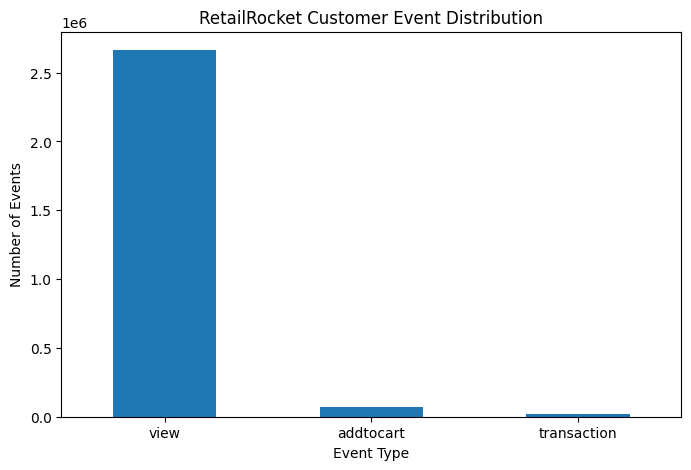

In [ ]:
event_counts = df["event"].value_counts()

plt.figure(figsize=(8, 5))
event_counts.plot(kind="bar")
plt.title("RetailRocket Customer Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Get visitors who have at least one transaction
purchase_visitors = df.loc[
    df["event"].eq("transaction"),
    "visitorid"
].unique()

# Get unique visitors
visitor_ids = df["visitorid"].unique()

# Create labels:
# 1 = Purchase
# 0 = No Purchase
y = np.isin(visitor_ids, purchase_visitors).astype("int8")

print(f"Total customers : {len(y):,}")
print(f"Purchase = 1    : {np.sum(y == 1):,}")
print(f"No purchase = 0 : {np.sum(y == 0):,}")

print("\nClass distribution:")

print(
    pd.Series(y)
    .value_counts()
    .rename(index={
        0: "No Purchase",
        1: "Purchase"
    })
)

Total customers : 1,407,580
Purchase = 1    : 11,719
No purchase = 0 : 1,395,861

Class distribution:
No Purchase    1395861
Purchase         11719
Name: count, dtype: int64


In [ ]:
print("Sorting data by visitor and timestamp...")

df = df.sort_values(
    ["visitorid", "timestamp"],
    kind="mergesort"
).reset_index(drop=True)

print(" Sorting completed")

print("\nFirst customer's chronological behavior:")

first_visitor = df["visitorid"].iloc[0]

display(
    df[df["visitorid"] == first_visitor]
    [["visitorid", "timestamp", "event", "event_encoded", "itemid"]]
    .head(20)
)

Sorting data by visitor and timestamp...
 Sorting completed

First customer's chronological behavior:


,visitorid,timestamp,event,event_encoded,itemid
0,0,1442004589439,view,1,285930
1,0,1442004759591,view,1,357564
2,0,1442004917175,view,1,67045


In [ ]:
MAX_LEN = 20

print(f"Maximum sequence length: {MAX_LEN}")

sequences = (
    df.groupby("visitorid", sort=False)["event_encoded"]
      .agg(lambda x: x.tolist()[:MAX_LEN])
      .tolist()
)

print(f"\n Sequences created: {len(sequences):,}")

Maximum sequence length: 20

✓ Sequences created: 1,407,580


In [ ]:
reverse_mapping = {
    1: "view",
    2: "addtocart",
    3: "transaction"
}

visitor_ids = df["visitorid"].drop_duplicates().head(5).tolist()

for visitor_id in visitor_ids:

    customer_events = (
        df[df["visitorid"] == visitor_id]["event_encoded"]
        .tolist()[:MAX_LEN]
    )

    readable_events = [
        reverse_mapping[event]
        for event in customer_events
    ]

    print(f"\nVisitor {visitor_id}")
    print("Encoded :", customer_events)
    print("Behavior:", " → ".join(readable_events))


Visitor 0
Encoded : [1, 1, 1]
Behavior: view → view → view

Visitor 1
Encoded : [1]
Behavior: view

Visitor 2
Encoded : [1, 1, 1, 1, 1, 1, 1, 1]
Behavior: view → view → view → view → view → view → view → view

Visitor 3
Encoded : [1]
Behavior: view

Visitor 4
Encoded : [1]
Behavior: view


In [ ]:
# Keep the exact visitor order used for sequences
visitor_ids = (
    df.groupby("visitorid", sort=False)
      .size()
      .index
)

# Visitors who made a transaction
purchase_visitors = set(
    df.loc[
        df["event"] == "transaction",
        "visitorid"
    ]
)

# Create label in exactly the same visitor order
y = np.array(
    [
        1 if visitor_id in purchase_visitors else 0
        for visitor_id in visitor_ids
    ],
    dtype="int8"
)

print(f"Total customers : {len(y):,}")
print(f"Purchase = 1    : {np.sum(y == 1):,}")
print(f"No purchase = 0 : {np.sum(y == 0):,}")

print("\nClass distribution:")

print(
    pd.Series(y)
    .value_counts()
    .rename(index={
        0: "No Purchase",
        1: "Purchase"
    })
)

Total customers : 1,407,580
Purchase = 1    : 11,719
No purchase = 0 : 1,395,861

Class distribution:
No Purchase    1395861
Purchase         11719
Name: count, dtype: int64


In [ ]:
features = [
    "event_type",
    "time_gap",
    "item_frequency",
    "session_event_count",
    "hour"
]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=10,
    batch_size=64,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/10
15396/15396 ━━━━━━━━━━━━━━━━━━━━ 154s 10ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 2/10
15396/15396 ━━━━━━━━━━━━━━━━━━━━ 202s 10ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 3/10
15396/15396 ━━━━━━━━━━━━━━━━━━━━ 212s 11ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 4/10
15396/15396 ━━━━━━━━━━━━━━━━━━━━ 155s 10ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 5/10
15396/15396 ━━━━━━━━━━━━━━━━━━━━ 154s 10ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 6/10
15396/15396 ━━━━━━━━━━━━━━━━━━━━ 153s 10ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 7/10
15396/15396 ━━━━━━━━━━━━━━━━━━━━ 153s 10ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9995 - val_loss: 0.0016


In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

probabilities = model.predict(X_test)

predictions = (probabilities >= 0.5).astype(int)

print(classification_report(y_test, predictions))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, probabilities)
)

6599/6599 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209488
           1       1.00      1.00      1.00      1649

    accuracy                           1.00    211137
   macro avg       1.00      1.00      1.00    211137
weighted avg       1.00      1.00      1.00    211137

ROC-AUC: 1.0


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

y_pred_prob = model.predict(X_test, batch_size=256)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Test loss
test_loss = log_loss(y_test, y_pred_prob)

print("\nCNN TEST RESULTS")
print("-" * 50)
print(f"Loss       : {test_loss:.4f}")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")

825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step

CNN TEST RESULTS
--------------------------------------------------
Loss       : 0.0013
Accuracy   : 0.9996
Precision  : 1.0000
Recall     : 0.9494
F1 Score   : 0.9740
ROC-AUC    : 0.9999


In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)


# Predict purchase probabilities
probabilities = model.predict(X_test, verbose=1).ravel()

# Convert probabilities to class predictions
predictions = (probabilities >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, zero_division=0)
recall = recall_score(y_test, predictions, zero_division=0)
f1 = f1_score(y_test, predictions, zero_division=0)
roc_auc = roc_auc_score(y_test, probabilities)
loss = log_loss(y_test, probabilities)

print("\nCNN PERFORMANCE")
print("-" * 50)

print(f"Loss       : {loss:.4f}")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")


print(
    classification_report(
        y_test,
        predictions,
        target_names=["No Purchase", "Purchase"],
        digits=4,
        zero_division=0
    )
)

print(f"ROC-AUC: {roc_auc:.4f}")

6599/6599 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step

CNN PERFORMANCE
--------------------------------------------------
Loss       : 0.0013
Accuracy   : 0.9996
Precision  : 1.0000
Recall     : 0.9494
F1 Score   : 0.9740
ROC-AUC    : 0.9999
              precision    recall  f1-score   support

 No Purchase     0.9996    1.0000    0.9998    209379
    Purchase     1.0000    0.9494    0.9740      1758

    accuracy                         0.9996    211137
   macro avg     0.9998    0.9747    0.9869    211137
weighted avg     0.9996    0.9996    0.9996    211137

ROC-AUC: 0.9999


In [ ]:
probabilities = model.predict(
    X_test,
    verbose=0
).ravel()

predictions = (
    probabilities >= 0.5
).astype(int)

In [ ]:
df["is_view"] = (df["event"] == "view").astype("int8")
df["is_cart"] = (df["event"] == "addtocart").astype("int8")
df["is_transaction"] = (df["event"] == "transaction").astype("int8")

In [ ]:
customer_features = (
    df.groupby("visitorid", sort=False)
      .agg(
          total_interactions=("event", "size"),
          view_count=("is_view", "sum"),
          cart_count=("is_cart", "sum"),
          transaction_count=("is_transaction", "sum"),
          unique_items=("itemid", "nunique")
      )
      .reset_index()
)

print(customer_features.shape)
display(customer_features.head())

(1407580, 6)


,visitorid,total_interactions,view_count,cart_count,transaction_count,unique_items
0,0,3,3,0,0,3
1,1,1,1,0,0,1
2,2,8,8,0,0,4
3,3,1,1,0,0,1
4,4,1,1,0,0,1


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Create row numbers for the original X dataset
all_indices = np.arange(len(X))

# Reproduce the SAME train/test splitting only for indices
train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=42,
    stratify=y
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Get customer IDs corresponding to X_test
test_customer_ids = customer_features.iloc[test_idx]["visitorid"].to_numpy()

print("Number of test customer IDs:", len(test_customer_ids))
print("Number of y_test:", len(y_test))
print("First 10 customer IDs:", test_customer_ids[:10])

Number of test customer IDs: 211137
Number of y_test: 211137
First 10 customer IDs: [ 629516 1063627 1143922 1015504 1210522  144909 1064019 1363511   31943
 1201655]


In [ ]:
results = pd.DataFrame({

    "customer_id": test_customer_ids,

    "actual_behavior": [
        "Purchase" if x == 1 else "No Purchase"
        for x in y_test
    ],

    "predicted_behavior": [
        "Purchase" if x == 1 else "No Purchase"
        for x in predictions
    ],

    "purchase_probability": probabilities,

    "confidence": np.where(
        predictions == 1,
        probabilities,
        1 - probabilities
    )
})

display(results.head(20))